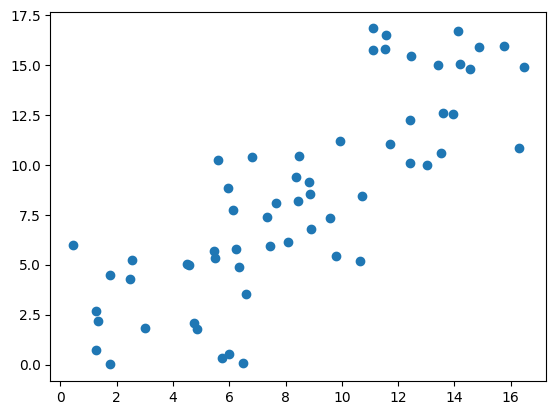

In [ ]:
import matplotlib.pyplot as plt
import copy
import numpy as np
from numpy.linalg import norm
from sklearn.cluster import KMeans

loaded_points = np.load('data/k_mean_points.npy')

plt.figure()
plt.scatter(loaded_points[:,0],loaded_points[:,1])

k = 3

def initialize_clusters(points: np.ndarray, k_clusters: int) -> np.ndarray:
    """
    Initializes and returns k random centroids from the given dataset.

    :param points: Array of data points.
    :type: points ndarray with shape (n, 2)

    :param k_clusters: The number of clusters to form
    :type k_clusters: int


    :return: initial_clusters
    initial_clusters: Array of initialized centroids

    :rtype:
    initial_clusters: np.array (k_clusters, 2)
    :

    """

    ###################################
    # Write your own code here #
    shuffled_points = copy.deepcopy(points)
    np.random.shuffle(shuffled_points)
    initial_clusters = shuffled_points[:k_clusters]

    ###################################

    return initial_clusters

In [ ]:
def calculate_metric(points: np.ndarray, centroid: np.ndarray) -> np.ndarray:
    """
    Calculates the distance metric between each point and a given centroid.

    Parameters:
    :param points: Array of n data points.
    :type points: ndarray with shape (n, 2)

    :param centroid: A single centroid
    :type centroid: ndarray with shape (1, 2)

    :return: distances_array
    distances_array: Array of distances from point to centroid

    :rtype:
    distances_array: ndarray with shape (n,)
    :
    """

    ###################################
    # Write your own code here #
    distances_array = np.linalg.norm(points - centroid, axis=1)


    ###################################

    return distances_array


print(calculate_metric(loaded_points, np.array([1, 1])))

[ 3.93120749  6.13751539  6.48048316  6.24105665  6.60896901  5.01967849
  3.89927114  5.34126427  4.53414797  0.39149733  1.25577685  4.77685081
  2.18426764  5.57177955  1.71856432  1.23608596  3.61990154  3.57935326
  5.02439002  5.34924743 11.17546938  8.99916755 11.05282741 10.34523657
 10.68782703 11.31809681  8.48293771 12.24774639  9.73460006 10.34251931
 10.50800476 13.5638176   9.84218079  7.10241432  8.10298879  9.79140711
  9.29000694 12.06528197 10.89642724  8.76320255 18.78508316 20.80286939
 18.44089771 18.71174788 17.11054226 20.48573655 17.34755861 16.04300698
 15.76630988 14.60165525 15.04567791 19.27690163 19.34429565 17.87610725
 18.19972781 18.20267201 20.36791466 21.02927848 18.79679699 14.68731656]


In [ ]:
def compute_distances(points: np.ndarray, centroids_points: np.ndarray) -> np.ndarray:
    """
    Computes and returns the distance from each point to each centroid.

    Parameters:
    :param points: Array of n data points.
    :type points: ndarray with shape (n, 2)

    :param centroids_points: A all centroid points
    :type centroids_points: ndarray with shape (k_clusters, 2)


    :return: distances_array
    distances_array: 2D array with distances of each point to each centroid.

    :rtype:
    distances_array: ndarray of shape (k_clusters, n)
    """
    ###################################
    # Write your own code here #

    k_clusters = centroids_points.shape[0]

    # Compute distance from each centroid to all points
    distances_array = np.array([
        calculate_metric(points, centroids_points[i])
        for i in range(k_clusters)
    ])
    ###################################

    return distances_array

print(compute_distances(loaded_points, np.array(([1, 1],[2,2]))))

[[ 3.93120749  6.13751539  6.48048316  6.24105665  6.60896901  5.01967849
   3.89927114  5.34126427  4.53414797  0.39149733  1.25577685  4.77685081
   2.18426764  5.57177955  1.71856432  1.23608596  3.61990154  3.57935326
   5.02439002  5.34924743 11.17546938  8.99916755 11.05282741 10.34523657
  10.68782703 11.31809681  8.48293771 12.24774639  9.73460006 10.34251931
  10.50800476 13.5638176   9.84218079  7.10241432  8.10298879  9.79140711
   9.29000694 12.06528197 10.89642724  8.76320255 18.78508316 20.80286939
  18.44089771 18.71174788 17.11054226 20.48573655 17.34755861 16.04300698
  15.76630988 14.60165525 15.04567791 19.27690163 19.34429565 17.87610725
  18.19972781 18.20267201 20.36791466 21.02927848 18.79679699 14.68731656]
 [ 2.85897454  4.83701689  5.0668732   4.8270877   5.21659816  4.27903064
   2.74160228  3.93179042  3.3090266   1.46964445  2.00414145  4.08122588
   1.01755343  4.88181818  1.0039068   0.68473362  2.35696933  2.50700428
   4.25645575  3.938315    9.76455077

In [ ]:
def assign_centroids(distances: np.ndarray) -> np.ndarray:
    """
    Assigns each point to the closest centroid based on the distances.

    Parameters:
    :param distances: 2D array with distances of each point to each centroid.
    :type distances: ndarray with shape (k_clusters, n)

    :return: assigned_clusters
    assigned_clusters: Array indicating the closest centroid for each data point.

    :rtype:
    assigned_centroids: ndarray with shape (1, n) and dtype = np.int32
    """

    ###################################
    # Write your own code here #

    assigned_centroids = np.argmin(distances, axis=0).astype(np.int32)
    ###################################

    return assigned_centroids

print(assign_centroids(compute_distances(loaded_points, np.array(([6, 0],[2,9])))))

[0 0 1 1 0 1 0 1 1 0 0 0 0 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1
 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [ ]:
def calculate_objective(assigned_centroids: np.ndarray, distances: np.ndarray) -> np.ndarray:
    """
    Calculates and returns the objective function value for the clustering.

    Parameters:
    :param assigned_centroids: Array indicating the cluster assignment for each point.
    :type assigned_centroids: ndarray with shape (1, n) and and dtype = np.int64

    :param distances: 2D array with distances of each point to each centroid
    :type distances: ndarray with shape (k_clusters, n) and and dtype = np.float64

    :return: onjective_function_value
    onjective_function_value: Objective function value.

    :rtype:
    onjective_function_value: float32


    """
    ###################################
    # Write your own code here #


    selected_distances = distances[assigned_centroids, np.arange(distances.shape[1])]

    objective_function_value = np.sum(selected_distances ** 2).astype(np.float32)

    ###################################

    return objective_function_value

In [ ]:
def calculate_new_centroids(points: np.ndarray, assigned_centroids: np.ndarray, k_clusters: int) -> np.ndarray:
    """
    Computes new centroids based on the current cluster assignments.

    Parameters:
    :param points: Array of n data points.
    :type points: ndarray with shape (n, 2)

    :param assigned_centroids: Array indicating the closest centroid for each data point.
    :type assigned_centroids: ndarray with shape (1, n) and dtype = np.int32


    :param k_clusters: Number of clusters.
    :type k_clusters: int


    :return: new_clusters
    new_clusters: new cluster points

    :rtype:
    new_clusters: ndarray with shape (1, n) and dtype = np.float32
    """

    ###################################
    # Write your own code here #

    new_clusters = np.zeros((k_clusters, points.shape[1]), dtype=np.float32)

    for k in range(k_clusters):
        cluster_points = points[assigned_centroids == k]
        if cluster_points.shape[0] > 0:
            new_clusters[k] = np.mean(cluster_points, axis=0)

    ###################################

    return new_clusters

In [ ]:
def fit(points: np.ndarray, k_clusters: int, n_of_oterations: int, error: float = 0.001) -> tuple:
    """
    Fits the k-means clustering model on the dataset.

    Parameters:
    :param points : Array of data points.
    :type points: ndarray with shape (n, 2) and dtype = np.float32

    :param k_clusters:  Number of clusters
    :type k_clusters: int

    :param n_of_oterations:  Maximum number of iterations
    :type n_of_oterations: int


    :param error: Threshold for convergence.
    :type error: float

    :return: centroid_points, last_objective
    centroid_points: final centroid points
    last_objective: final objective funtion

    :rtype:
    centroid_points: ndarray with shape (k_clusters, 2) and dtype = np.float32
    last_objective: float

    """

    ###################################
    # Write your own code here #


    centroid_points = initialize_clusters(points, k_clusters).astype(np.float32)
    last_objective = np.float32(1e10)

    for _ in range(n_of_oterations):


        distances = compute_distances(points, centroid_points)
        assigned_centroids = assign_centroids(distances)
        current_objective = calculate_objective(assigned_centroids, distances)

        if np.abs(last_objective - current_objective) < error:
            break

        last_objective = current_objective

        centroid_points = calculate_new_centroids(
            points, assigned_centroids, k_clusters
        ).astype(np.float32)

    ###################################

    return centroid_points, last_objective

Final objective: 436.25195
Centroids:
 [[13.241031  13.810112 ]
 [ 3.4918408  2.7076254]
 [ 7.782291   7.5234804]]


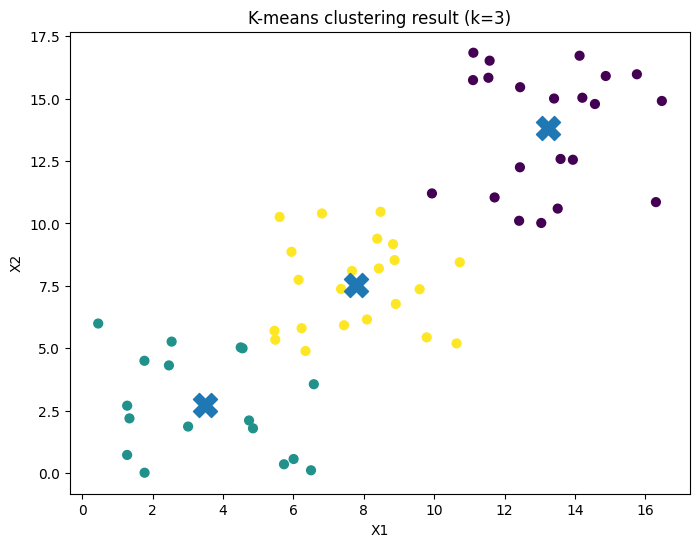

In [63]:
k = 3
centroids, objective = fit(loaded_points.astype(np.float32),
                           k_clusters=k,
                           n_of_oterations=100)

print("Final objective:", objective)
print("Centroids:\n", centroids)


distances = compute_distances(loaded_points, centroids)
assigned = assign_centroids(distances)


plt.figure(figsize=(8,6))

plt.scatter(loaded_points[:, 0],
            loaded_points[:, 1],
            c=assigned,
            cmap="viridis",
            s=40)

plt.scatter(centroids[:, 0],
            centroids[:, 1],
            marker="X",
            s=300)

plt.title("K-means clustering result (k=3)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

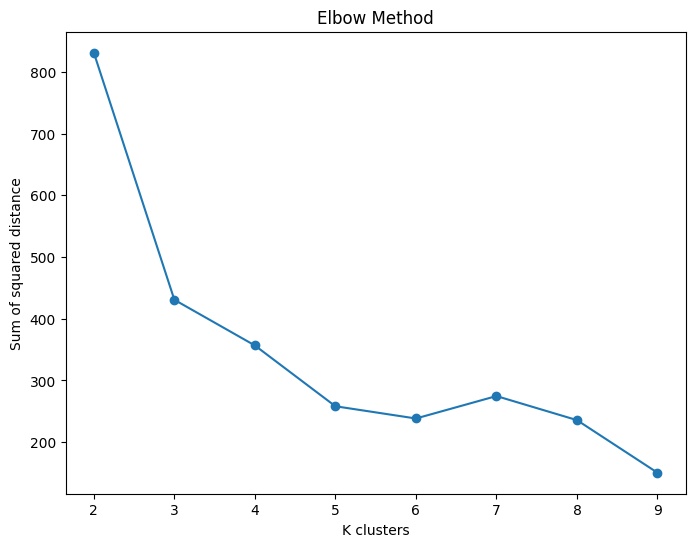

In [60]:
k_all = range(2, 10)
all_objective = []

for k in k_all:
    centroids, objective = fit(
        loaded_points.astype(np.float32),
        k_clusters=k,
        n_of_oterations=100
    )
    all_objective.append(objective)

plt.figure(figsize=(8,6))
plt.plot(k_all, all_objective, marker='o')
plt.xlabel('K clusters')
plt.ylabel('Sum of squared distance')
plt.title('Elbow Method')
plt.show()

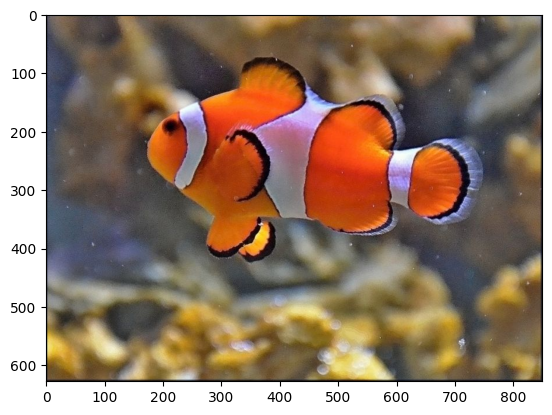

In [44]:
from matplotlib.image import imread
from sklearn.cluster import KMeans
import numpy as np

loaded_image = imread('data/fish.jpg')

plt.imshow(loaded_image)
plt.show()

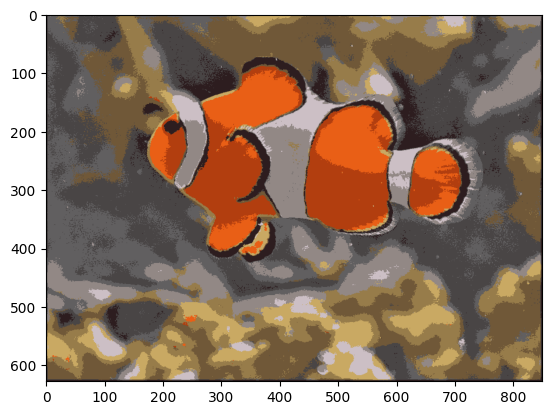

In [58]:
def compress_image(image: np.ndarray, number_of_colours: int) -> np.ndarray:

    original_shape = image.shape

    pixels = image.reshape(-1, original_shape[2])

    kmeans = KMeans(n_clusters=number_of_colours, random_state=102)
    kmeans.fit(pixels)

    new_colours = kmeans.cluster_centers_.astype(np.uint8)

    labels = kmeans.labels_
    compressed_pixels = new_colours[labels]

    compressed_image = compressed_pixels.reshape(original_shape)

    return compressed_image

img = compress_image(loaded_image, 10)

plt.figure()
plt.imshow(img)
plt.show()